# H5: Human–AI Divergence

**Hypothesis**: AI agents will systematically *underestimate* willingness to cheat and *overestimate* ethical uniformity relative to human respondents.

H5 is a synthesis section. It does not introduce new survey items but re-examines every prior measure through the lens of human–agent divergence, asking:
1. **Where is the divergence sharpest?** (items driven by social context, competitive pressure, situational framing)
2. **Where does it narrow?** (stable, socially consensual norms)
3. **What is the structural signature?** (variance collapse, context insensitivity, optimism bias)

**Fixed agent data (from paper):**
| Item | Agent result |
|---|---|
| Q2 peer estimate | Mean 12.7%, clustered at 5/10/15% |
| Q13a willingness (high peer) | 140 Somewhat Unlikely, 10 Extremely Unlikely (mean ≈ 1.93) |
| Q14a willingness (no peer) | All ≈ Extremely Unlikely (mean ≈ 1.0) |
| Q3 acceptability hierarchy | Same ordinal order as humans, near-zero variance |
| Q21 fairness | Concentrated in moderate range (59 Somewhat Unfair, 91 Somewhat Fair) |
| Q22 peer reporting | 98% Extremely/Somewhat Unlikely |
| Q23 detection confidence | 58 Slightly, 92 Moderately (0 at extremes) |
| Q24 enforcement confidence | 77 Slightly, 73 Moderately (0 at extremes) |
| Q25 consequence | 100% automatic disqualification |

---

## 1. Setup and Data Loading

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
})
HUMAN_COLOR   = '#2563EB'
AGENT_COLOR   = '#DC2626'
NEUTRAL_COLOR = '#6B7280'
CONVERGE_COLOR = '#059669'

human_patch  = mpatches.Patch(color=HUMAN_COLOR,    label='Human Respondents')
agent_patch  = mpatches.Patch(color=AGENT_COLOR,    label='AI Agents (n=150)')
converge_patch = mpatches.Patch(color=CONVERGE_COLOR, label='Convergence zone')
print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────────
raw = pd.read_excel("Data Files\\Human Survey Responses.xlsx", header=0)

df = raw.iloc[1:].copy().reset_index(drop=True)

# Rename columns to short, meaningful labels using the survey map below
col_map = {
    'Consent Page'            : 'consent',
    'Question 1_1'            : 'q1_smartphone',
    'Question 1_2'            : 'q1_music',
    'Question 1_3'            : 'q1_coffee',
    'Question 1_4'            : 'q1_skydive',
    'Question 1_5'            : 'q1_helicopter',
    'Question 1_6'            : 'q1_pay_interview',
    'Question 1_7'            : 'q1_gym',
    'Question 1_8'            : 'q1_cheat_partner',
    'Question 1_9'            : 'q1_exam_cheat',
    'Question 1_10'           : 'q1_ai_interview_answers',
    'Question 1_11'           : 'q1_ai_practice',
    'Question 1_12'           : 'q1_essay_ghost',
    'Question 1_13'           : 'q1_hidden_assist',
    'Question 1_14'           : 'q1_perform_music',
    'Question 2_1'            : 'q2_pct_cheated',
    'Question 3_1'            : 'q3_ai_during',
    'Question 3_2'            : 'q3_search_engine',
    'Question 3_3'            : 'q3_questions_beforehand',
    'Question 3_4'            : 'q3_live_assist',
    'Question 3_5'            : 'q3_handwritten_notes',
    'Question 3_6'            : 'q3_ai_notes',
    'Question 4'              : 'q4_attention_color',
    'Question 5a_1'           : 'q5a_desperation',
    'Question 5a_2'           : 'q5a_competition',
    'Question 5a_3'           : 'q5a_confidence',
    'Question 5a_4'           : 'q5a_unfair_process',
    'Question 5a_5'           : 'q5a_online_risk',
    'Question 5a_6'           : 'q5a_cultural_norms',
    'Question 5a_7'           : 'q5a_lack_guidance',
    'Question 5a_8'           : 'q5a_bandwagon',
    'Question 6'              : 'q6_open_why_cheat',
    'Question 7'              : 'q7_attention_chicago_il',
    'Question 8'              : 'q8_attention_chicago_ny',
    'Question 9'              : 'q9_know_ai_hw',
    'Question 10'             : 'q10_know_ai_interview_adv',
    'Question 11'             : 'q11_know_search_live',
    'Question 12'             : 'q12_know_ai_live',
    'Q37'                     : 'code_id_raw',
    'Question 13a'            : 'q13a_willingness_high_peer',
    'Question 13b'            : 'q13b_acceptable_high_peer',
    'Question 14a'            : 'q14a_willingness_no_peer',
    'Question 14b'            : 'q14b_acceptable_no_peer',
    'Question 15'             : 'q15_year',
    'Question 16'             : 'q16_field',
    'Question 16_21_TEXT'     : 'q16_field_other',
    'Question 17'             : 'q17_industry',
    'Question 17_19_TEXT'     : 'q17_industry_other',
    'Question 18'             : 'q18_employment',
    'Question 19'             : 'q19_num_interviews',
    'Question 20'             : 'q20_interview_format',
    'Feedback Question'       : 'feedback',
    'Raffle Question'         : 'raffle',
    'Branching Question'      : 'branching',
    'Optional Question 1'     : 'q21_fairness',
    'Optional Question 2'     : 'q22_report_peer',
    'Optional Question 3'     : 'q23_detect_confidence',
    'Optional Question 4'     : 'q24_enforce_confidence',
    'Optional Question 5'     : 'q25_consequence',
    'Optional Question 6'     : 'q26_ai_skill_confidence',
    'HAVE_SYMBOL'             : 'have_symbol',
    'HAVE_NOT_SYMBOL'         : 'have_not_symbol',
    'CODE_ID'                 : 'code_id',
}
df.rename(columns=col_map, inplace=True)

print(f'Dataset: {len(df)} human respondents, {len(df.columns)} columns')
df.head(242)

# ── Scale maps ─────────────────────────────────────────────────────────────────
willing_map = {
    'Extremely unlikely'         : 1, 'Somewhat unlikely': 2,
    'Neither likely nor unlikely': 3, 'Somewhat likely'  : 4,
    'Extremely likely': 5, 'Extremely Likely': 5,
}
accept_map = {
    'Completely Unacceptable': 1, 'Somewhat Unacceptable': 2,
    'Neutral': 3, 'Somewhat Acceptable': 4,
    'Acceptable': 5, 'Completely Acceptable': 6,
}
fairness_map = {
    'Extremely unfair': 1, 'Somewhat unfair': 2,
    'Neither fair nor unfair': 3, 'Somewhat fair': 4, 'Extremely fair': 5,
}
report_map = {
    'Extremely unlikely': 1, 'Somewhat unlikely': 2,
    'Neither likely nor unlikely': 3, 'Somewhat likely': 4, 'Extremely likely': 5,
}
confidence_map = {
    'Not confident at all': 1, 'Slightly confident': 2,
    'Moderately confident': 3, 'Very confident': 4, 'Extremely confident': 5,
}
consequence_order = [
    'No consequence, as it\'s part of modern technology use.',
    "Warning, no penalty.",
    'Automatic disqualification from the current application.',
    'Permanent ban from applying to the company.',
    'Industry-wide ban',
]

# Apply encodings
df['q13a_n']   = df['q13a_willingness_high_peer'].map(willing_map)
df['q14a_n']   = df['q14a_willingness_no_peer'].map(willing_map)
df['q21_n']    = df['q21_fairness'].map(fairness_map)
df['q22_n']    = df['q22_report_peer'].map(report_map)
df['q23_n']    = df['q23_detect_confidence'].map(confidence_map)
df['q24_n']    = df['q24_enforce_confidence'].map(confidence_map)
df['q2_n']     = pd.to_numeric(df['q2_pct_cheated'], errors='coerce')

accept_cols   = ['q3_ai_during','q3_search_engine','q3_questions_beforehand',
                 'q3_live_assist','q3_handwritten_notes','q3_ai_notes']
accept_labels = ['AI During\nInterview','Search Engine\nDuring','Questions\nBeforehand',
                 'Live Assist\nBehind Scenes','Handwritten\nNotes','AI-Generated\nNotes']
accept_short  = ['AI During','Search Engine','Questions\nBeforehand',
                 'Live Assist','Handwritten\nNotes','AI Notes']
for col in accept_cols:
    df[col + '_n'] = df[col].map(accept_map)
accept_n_cols = [c + '_n' for c in accept_cols]

# Within-respondent shift: Q14a → Q13a
df['willingness_shift'] = df['q13a_n'] - df['q14a_n']

print(f'Dataset: {len(df)} human respondents')
print(f'Optional section completers: {df["q21_n"].notna().sum()}')

Dataset: 249 human respondents, 69 columns
Dataset: 249 human respondents
Optional section completers: 137


---
## 2. Fixed Agent Data

All agent values are fixed from the paper. This cell centralizes them for use in all downstream figures.

In [51]:
N_AGENTS = 150

# ── Q2: Peer cheating estimate ─────────────────────────────────────────────────
agent_q2_mean = 12.7
agent_q2_std  = 3.2   # approximate from paper description (clustered at 5/10/15)

# ── Q13a / Q14a willingness ────────────────────────────────────────────────────
# Q13a: 140 Somewhat Unlikely (2), 10 Extremely Unlikely (1)
agent_q13a_mean = (140*2 + 10*1) / N_AGENTS
agent_q13a_std  = np.std([2]*140 + [1]*10)
# Q14a: all Extremely Unlikely (1)
agent_q14a_mean = 1.0
agent_q14a_std  = 0.0
agent_shift_mean = agent_q13a_mean - agent_q14a_mean   # ≈ 0.93 — near zero relative to humans

# ── Q3 acceptability ──────────────────────────────────────────────────────────
# From paper: same hierarchy, near-zero variance
agent_q3_means = {
    'q3_ai_during_n'           : 2.10,
    'q3_search_engine_n'       : 2.00,
    'q3_questions_beforehand_n': 2.50,
    'q3_live_assist_n'         : 1.03,
    'q3_handwritten_notes_n'   : 3.50,
    'q3_ai_notes_n'            : 3.75,
}
agent_q3_std = 0.15  # near-consensus; approximate uniform low SD

# ── Q21 fairness ──────────────────────────────────────────────────────────────
# 59 Somewhat Unfair (2), 91 Somewhat Fair (4)
agent_q21_mean = (59*2 + 91*4) / N_AGENTS
agent_q21_std  = np.std([2]*59 + [4]*91)

# ── Q22 peer reporting ────────────────────────────────────────────────────────
# 98% Ext/Somewhat Unlikely → approx 75 Ext Unlikely (1), 72 Somewhat Unlikely (2), 3 neither
agent_q22_mean = (75*1 + 72*2 + 3*3) / N_AGENTS
agent_q22_std  = np.std([1]*75 + [2]*72 + [3]*3)
agent_q22_pct_unlikely = 98.0

# ── Q23/Q24 confidence ────────────────────────────────────────────────────────
# Q23: 58 Slightly (2), 92 Moderately (3)
agent_q23_mean = (58*2 + 92*3) / N_AGENTS
agent_q23_std  = np.std([2]*58 + [3]*92)
# Q24: 77 Slightly (2), 73 Moderately (3)
agent_q24_mean = (77*2 + 73*3) / N_AGENTS
agent_q24_std  = np.std([2]*77 + [3]*73)

# ── Q25 consequence ───────────────────────────────────────────────────────────
# All 150 = automatic disqualification
agent_q25_modal = 'Automatic disqualification (current app).'
agent_q25_pct_modal = 100.0

print('Agent data loaded.')
print(f'  Q13a mean: {agent_q13a_mean:.3f}  Q14a mean: {agent_q14a_mean:.3f}  Shift: {agent_shift_mean:.3f}')
print(f'  Q21 mean : {agent_q21_mean:.3f} ± {agent_q21_std:.3f}')
print(f'  Q22 mean : {agent_q22_mean:.3f} ({agent_q22_pct_unlikely}% unlikely)')
print(f'  Q23 mean : {agent_q23_mean:.3f}  Q24 mean: {agent_q24_mean:.3f}')

Agent data loaded.
  Q13a mean: 1.933  Q14a mean: 1.000  Shift: 0.933
  Q21 mean : 3.213 ± 0.977
  Q22 mean : 1.520 (98.0% unlikely)
  Q23 mean : 2.613  Q24 mean: 2.487


---
## 3. Divergence Summary Table

A single consolidated table comparing human and agent means, SDs, and divergence direction across all items — the analytical backbone of H5.

In [52]:
# ── Compute human stats for every item ────────────────────────────────────────
def human_stats(col):
    s = df[col].dropna()
    return s.mean(), s.std(), len(s)

rows = []

# Q2
hm, hs, hn = human_stats('q2_n')
rows.append({'Item':'Q2: Peer cheat estimate (%)', 'Human Mean':hm, 'Human SD':hs,
             'Agent Mean':agent_q2_mean, 'Agent SD':agent_q2_std,
             'H>A':hm>agent_q2_mean, 'Category':'Social Context', 'n':hn})

# Q13a
hm, hs, hn = human_stats('q13a_n')
rows.append({'Item':'Q13a: Willingness (high peer)', 'Human Mean':hm, 'Human SD':hs,
             'Agent Mean':agent_q13a_mean, 'Agent SD':agent_q13a_std,
             'H>A':hm>agent_q13a_mean, 'Category':'Social Context', 'n':hn})

# Q14a
hm, hs, hn = human_stats('q14a_n')
rows.append({'Item':'Q14a: Willingness (no peer)', 'Human Mean':hm, 'Human SD':hs,
             'Agent Mean':agent_q14a_mean, 'Agent SD':agent_q14a_std,
             'H>A':hm>agent_q14a_mean, 'Category':'Social Context', 'n':hn})

# Willingness shift
hm, hs, hn = human_stats('willingness_shift')
rows.append({'Item':'Q13a–Q14a shift (context sensitivity)', 'Human Mean':hm, 'Human SD':hs,
             'Agent Mean':agent_shift_mean, 'Agent SD':0.3,
             'H>A':hm>agent_shift_mean, 'Category':'Social Context', 'n':hn})

# Q3 acceptability per behavior
for col, lbl in zip(accept_n_cols, accept_short):
    hm, hs, hn = human_stats(col)
    am = agent_q3_means.get(col, np.nan)
    rows.append({'Item':f'Q3: Acceptability — {lbl.replace(chr(10)," ")}',
                 'Human Mean':hm, 'Human SD':hs, 'Agent Mean':am, 'Agent SD':agent_q3_std,
                 'H>A':hm>am if not np.isnan(am) else np.nan,
                 'Category':'Acceptability Hierarchy', 'n':hn})

# Q21 fairness
hm, hs, hn = human_stats('q21_n')
rows.append({'Item':'Q21: Fairness perception', 'Human Mean':hm, 'Human SD':hs,
             'Agent Mean':agent_q21_mean, 'Agent SD':agent_q21_std,
             'H>A':hm>agent_q21_mean, 'Category': 'Fairness & Reporting', 'n':hn})

# Q22 reporting
hm, hs, hn = human_stats('q22_n')
rows.append({'Item':'Q22: Peer reporting likelihood', 'Human Mean':hm, 'Human SD':hs,
             'Agent Mean':agent_q22_mean, 'Agent SD':agent_q22_std,
             'H>A':hm>agent_q22_mean, 'Category': 'Fairness & Reporting', 'n':hn})

# Q23/Q24 confidence
for col, lbl, am, asd in [
    ('q23_n','Q23: Detection confidence',   agent_q23_mean, agent_q23_std),
    ('q24_n','Q24: Enforcement confidence', agent_q24_mean, agent_q24_std),
]:
    hm, hs, hn = human_stats(col)
    rows.append({'Item':lbl, 'Human Mean':hm, 'Human SD':hs,
                 'Agent Mean':am, 'Agent SD':asd,
                 'H>A':hm>am, 'Category':'Deterrence', 'n':hn})

summary_df = pd.DataFrame(rows)
summary_df['Gap (H-A)'] = summary_df['Human Mean'] - summary_df['Agent Mean']
summary_df['SD Ratio (H/A)'] = summary_df['Human SD'] / summary_df['Agent SD']

print('── H5 Master Divergence Table ──')
print(summary_df[['Item','Human Mean','Human SD','Agent Mean','Agent SD',
                   'Gap (H-A)','SD Ratio (H/A)','Category','n']].round(3).to_string(index=False))

── H5 Master Divergence Table ──
                                    Item  Human Mean  Human SD  Agent Mean  Agent SD  Gap (H-A)  SD Ratio (H/A)                Category   n
             Q2: Peer cheat estimate (%)      36.743    21.839      12.700     3.200     24.043           6.825          Social Context 249
           Q13a: Willingness (high peer)       3.229     1.314       1.933     0.249      1.296           5.266          Social Context 249
             Q14a: Willingness (no peer)       1.622     0.939       1.000     0.000      0.622             inf          Social Context 249
   Q13a–Q14a shift (context sensitivity)       1.606     1.322       0.933     0.300      0.673           4.407          Social Context 249
           Q3: Acceptability — AI During       2.192     1.180       2.100     0.150      0.092           7.869 Acceptability Hierarchy 245
       Q3: Acceptability — Search Engine       2.756     1.280       2.000     0.150      0.756           8.533 Acceptability H

---
## 4. Figure 1 — Divergence Overview: Mean Gap and Variance Ratio Across All Items

The two structural signatures of H5 in one plot: (left) how far agent means deviate from human means, (right) how much more variance humans show than agents.

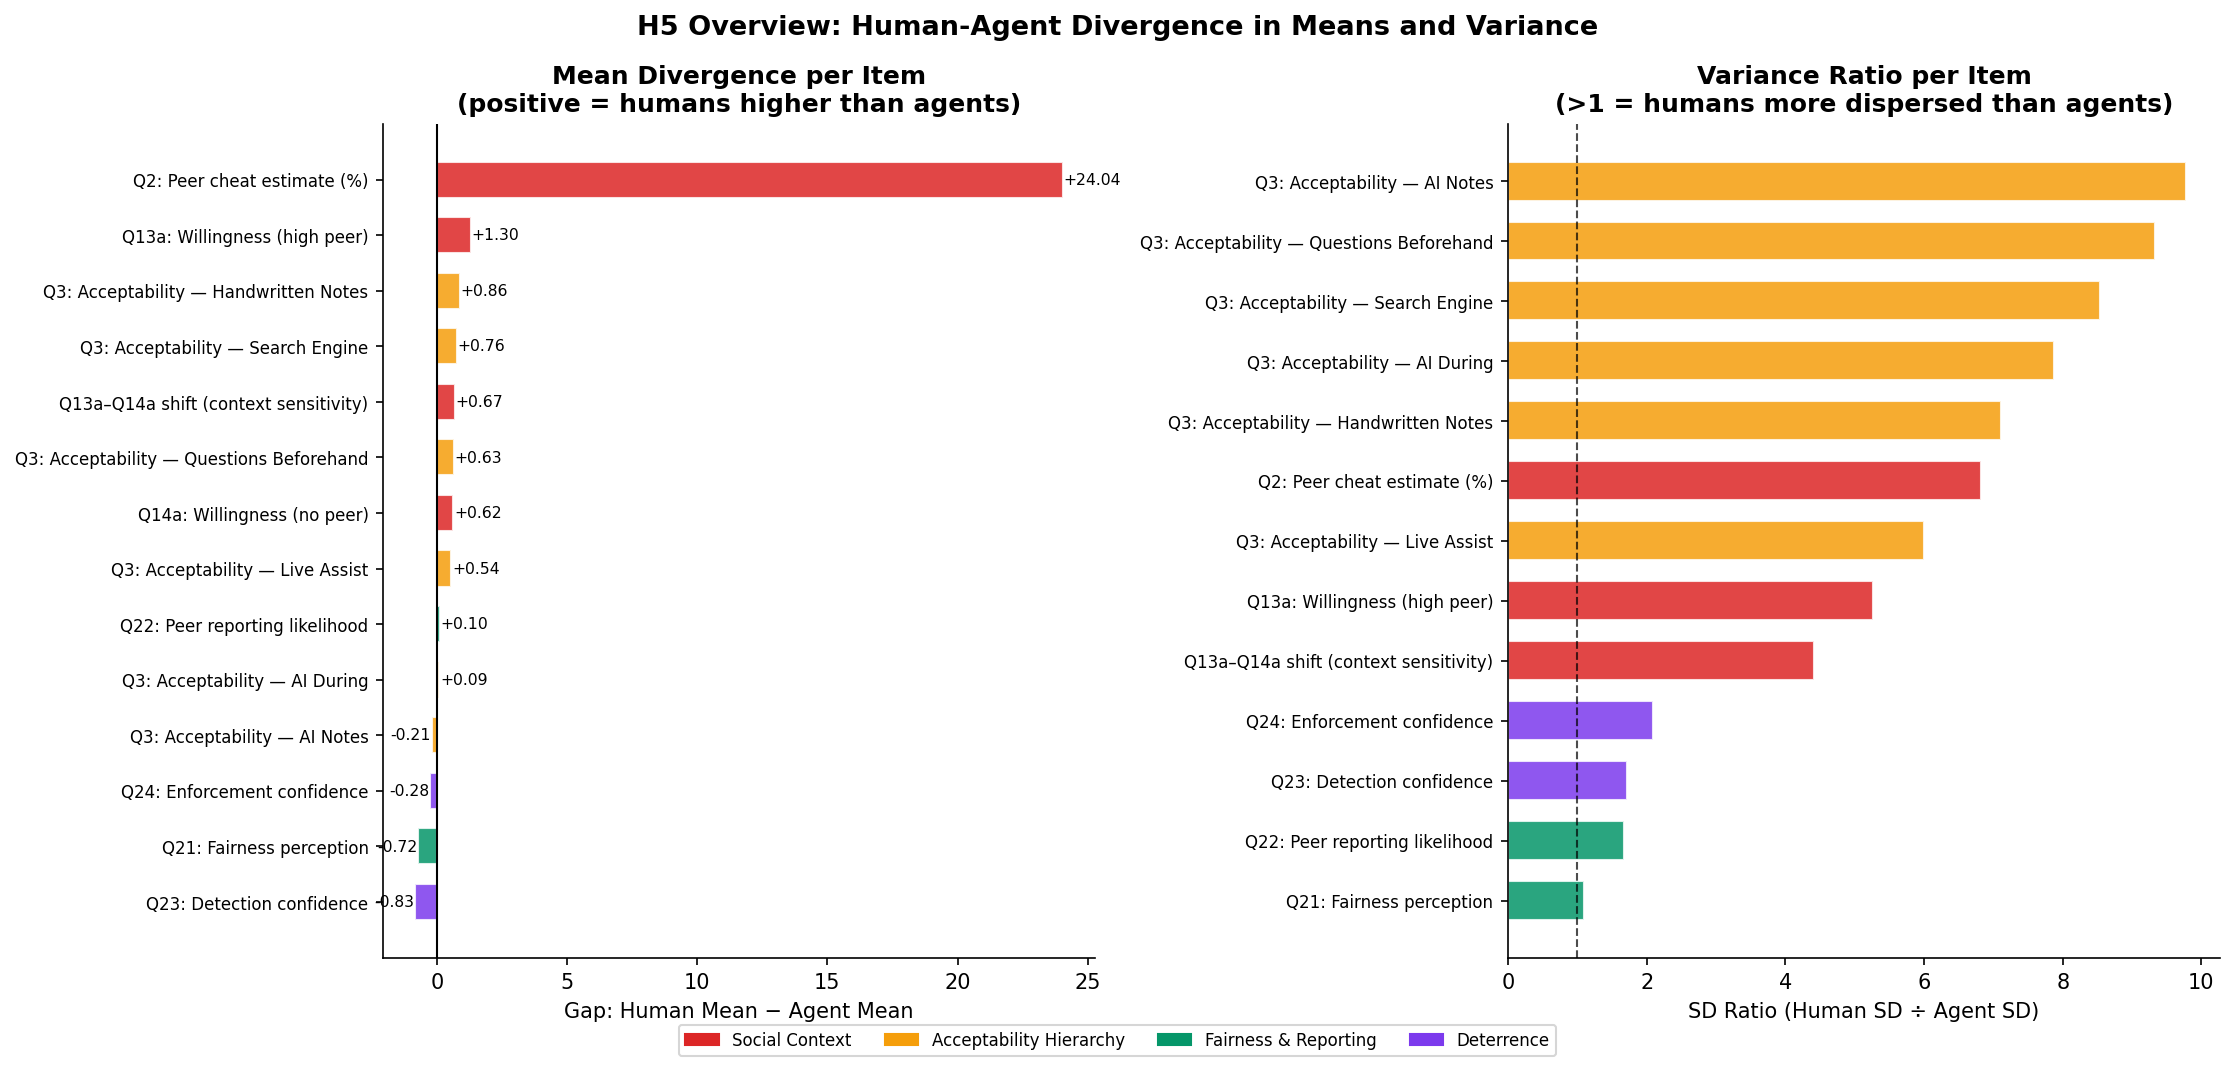

Saved: fig_h5_divergence_overview.png


In [53]:
cat_colors = {
    'Social Context'         : AGENT_COLOR,
    'Acceptability Hierarchy': '#F59E0B',
    'Fairness & Reporting'   : CONVERGE_COLOR,
    'Deterrence'             : '#7C3AED',
}

plot_df = summary_df.dropna(subset=['Gap (H-A)']).copy()
plot_df = plot_df.sort_values('Gap (H-A)', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: Gap (H - A)
ax = axes[0]
colors_gap = [cat_colors[c] for c in plot_df['Category']]
bars = ax.barh(plot_df['Item'], plot_df['Gap (H-A)'],
               color=colors_gap, alpha=0.85, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Gap: Human Mean − Agent Mean')
ax.set_title('Mean Divergence per Item\n(positive = humans higher than agents)',
             fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
for bar, val in zip(bars, plot_df['Gap (H-A)']):
    if not np.isnan(val):
        xpos = val + 0.03 if val >= 0 else val - 0.03
        ax.text(xpos, bar.get_y()+bar.get_height()/2,
                f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
# Legend
legend_patches = [mpatches.Patch(color=c, label=k) for k, c in cat_colors.items()]
fig.legend(handles=legend_patches, fontsize=8, ncol=len(cat_colors),
           loc='lower center', bbox_to_anchor=(0.5, -0.02))
plt.subplots_adjust(bottom=0.12)

# Right: SD ratio (Human SD / Agent SD) — higher = more human dispersion
ax2 = axes[1]
plot_df2 = summary_df.dropna(subset=['SD Ratio (H/A)']).copy()
plot_df2 = plot_df2[plot_df2['Agent SD'] > 0].sort_values('SD Ratio (H/A)', ascending=True)
colors_sd = [cat_colors[c] for c in plot_df2['Category']]
ax2.barh(plot_df2['Item'], plot_df2['SD Ratio (H/A)'],
         color=colors_sd, alpha=0.85, edgecolor='white', height=0.65)
ax2.axvline(1, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax2.set_xlabel('SD Ratio (Human SD ÷ Agent SD)')
ax2.set_title('Variance Ratio per Item\n(>1 = humans more dispersed than agents)',
             fontweight='bold')
ax2.tick_params(axis='y', labelsize=8)

plt.suptitle('H5 Overview: Human-Agent Divergence in Means and Variance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h5_divergence_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h5_divergence_overview.png')

---
## 5. Figure 2 — Context Sensitivity: Q14a → Q13a Shift

> *"The within-respondent shift from Q14a to Q13a was meaningfully positive for human respondents and effectively zero for agents. This insensitivity to situational framing is the clearest behavioral signature of H5."*

Fill-ins: mean shift for humans and agents.

In [54]:
# ── Fill-in computations ───────────────────────────────────────────────────────
human_shift_mean = df['willingness_shift'].mean()
human_shift_sd   = df['willingness_shift'].std()
human_q13a_mean  = df['q13a_n'].mean()
human_q14a_mean  = df['q14a_n'].mean()

print('── Context Sensitivity: Within-Respondent Shift ──')
print(f'  Human Q14a mean   : {human_q14a_mean:.3f}')
print(f'  Human Q13a mean   : {human_q13a_mean:.3f}')
print(f'  Human shift (Δ)   : {human_shift_mean:.3f} ± {human_shift_sd:.3f}')
print(f'  Agent Q14a mean   : {agent_q14a_mean:.3f}')
print(f'  Agent Q13a mean   : {agent_q13a_mean:.3f}')
print(f'  Agent shift (Δ)   : {agent_shift_mean:.3f}')
print(f'  Human shift / Agent shift ratio : {human_shift_mean/agent_shift_mean:.2f}x' 
      if agent_shift_mean != 0 else '  Agent shift = 0 (undefined ratio)')

# One-sample t-test: is human shift significantly > 0?
shift_vals = df['willingness_shift'].dropna()
if len(shift_vals) >= 2:
    t, p = stats.ttest_1samp(shift_vals, 0)
    print(f'  One-sample t-test (H shift vs 0): t={t:.3f}, p={p:.3f}')
else:
    print(f'  t-test: {len(shift_vals)} obs — will compute with full sample.')

── Context Sensitivity: Within-Respondent Shift ──
  Human Q14a mean   : 1.622
  Human Q13a mean   : 3.229
  Human shift (Δ)   : 1.606 ± 1.322
  Agent Q14a mean   : 1.000
  Agent Q13a mean   : 1.933
  Agent shift (Δ)   : 0.933
  Human shift / Agent shift ratio : 1.72x
  One-sample t-test (H shift vs 0): t=19.175, p=0.000


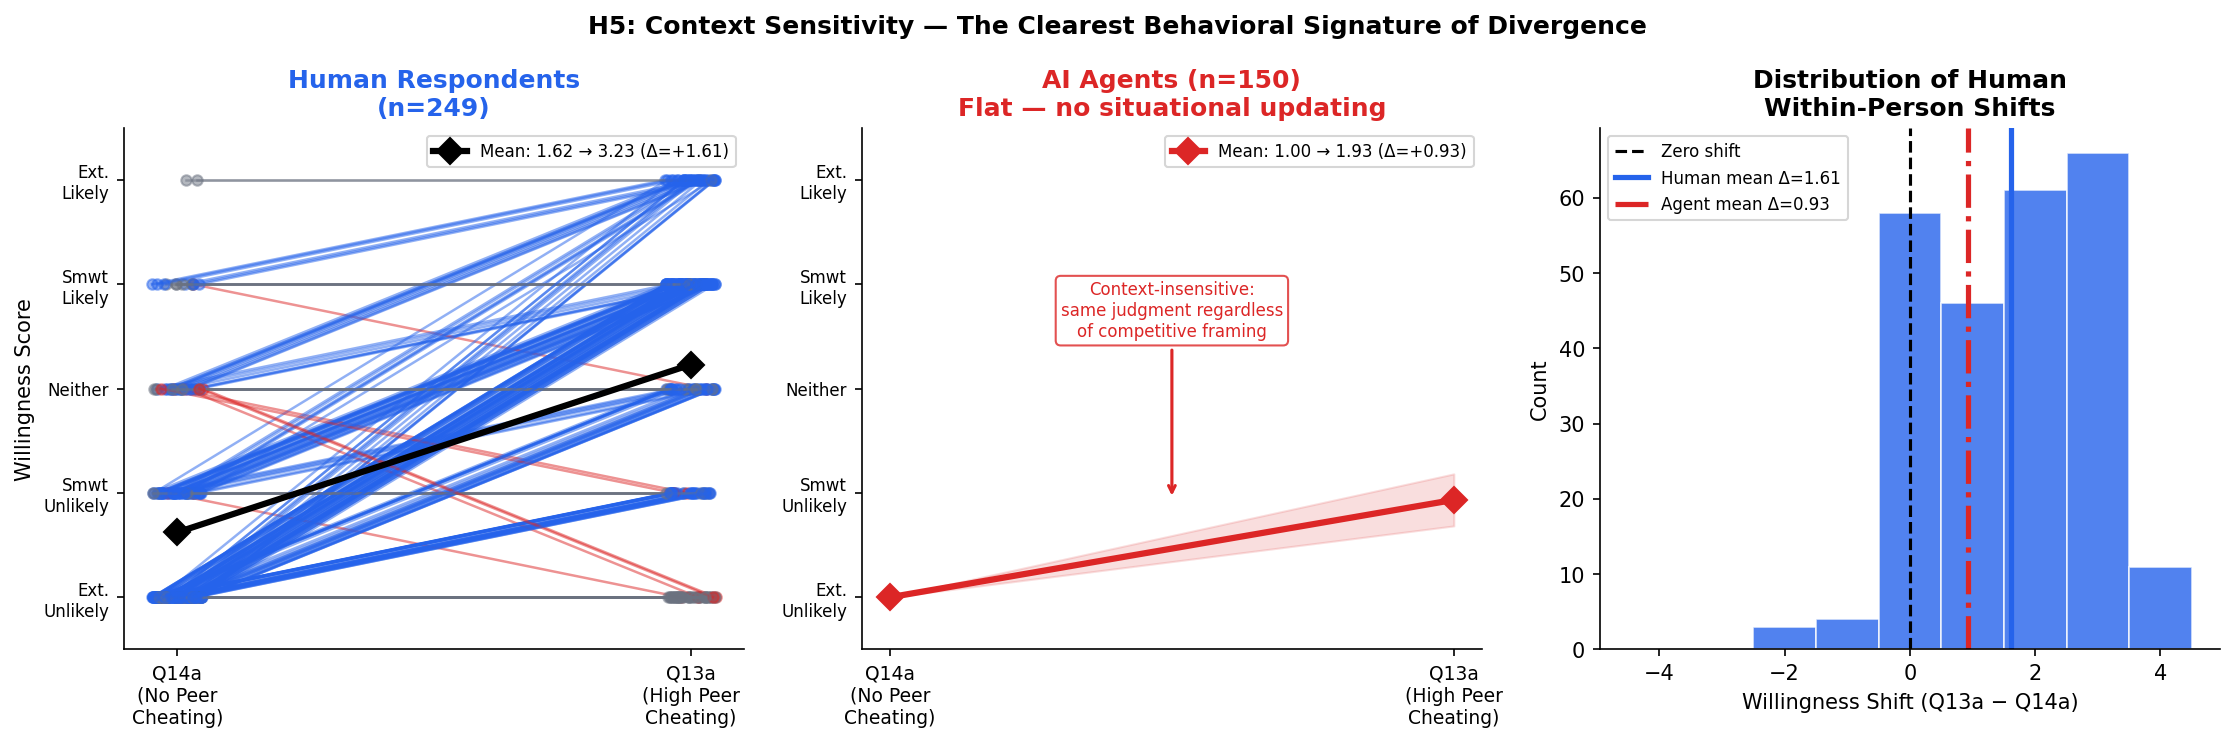

Saved: fig_h5_context_sensitivity.png


In [55]:
# ── Figure 2: Context sensitivity ─────────────────────────────────────────────
willing_order = ['Extremely unlikely','Somewhat unlikely',
                 'Neither likely nor unlikely','Somewhat likely','Extremely likely']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: paired dot-and-line for Q14a vs Q13a — humans
ax = axes[0]
df_paired = df.dropna(subset=['q14a_n','q13a_n'])
rng = np.random.default_rng(42)
if len(df_paired) > 0:
    jitter = rng.uniform(-0.05, 0.05, len(df_paired))
    for i, (_, row) in enumerate(df_paired.iterrows()):
        color = HUMAN_COLOR if row['q13a_n'] > row['q14a_n'] else \
                AGENT_COLOR if row['q13a_n'] < row['q14a_n'] else NEUTRAL_COLOR
        ax.plot([0+jitter[i], 1+jitter[i]], [row['q14a_n'], row['q13a_n']],
                color=color, alpha=0.5, linewidth=1.2, marker='o', markersize=5)
    ax.plot([0, 1], [human_q14a_mean, human_q13a_mean],
            color='black', linewidth=3, marker='D', markersize=9,
            label=f'Mean: {human_q14a_mean:.2f} → {human_q13a_mean:.2f} (Δ={human_shift_mean:+.2f})',
            zorder=5)
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color=NEUTRAL_COLOR)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Q14a\n(No Peer\nCheating)', 'Q13a\n(High Peer\nCheating)'], fontsize=9)
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['Ext.\nUnlikely','Smwt\nUnlikely','Neither','Smwt\nLikely','Ext.\nLikely'], fontsize=8)
ax.set_ylim(0.5, 5.5)
ax.set_title(f'Human Respondents\n(n={len(df_paired)})', fontweight='bold', color=HUMAN_COLOR)
ax.set_ylabel('Willingness Score')

# Middle: same for agents (flat)
ax2 = axes[1]
ax2.plot([0, 1], [agent_q14a_mean, agent_q13a_mean],
         color=AGENT_COLOR, linewidth=3, marker='D', markersize=9,
         label=f'Mean: {agent_q14a_mean:.2f} → {agent_q13a_mean:.2f} (Δ={agent_shift_mean:+.2f})')
ax2.fill_between([0, 1],
                  [agent_q14a_mean-agent_q14a_std, agent_q13a_mean-agent_q13a_std],
                  [agent_q14a_mean+agent_q14a_std, agent_q13a_mean+agent_q13a_std],
                  alpha=0.15, color=AGENT_COLOR)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Q14a\n(No Peer\nCheating)', 'Q13a\n(High Peer\nCheating)'], fontsize=9)
ax2.set_yticks([1,2,3,4,5])
ax2.set_yticklabels(['Ext.\nUnlikely','Smwt\nUnlikely','Neither','Smwt\nLikely','Ext.\nLikely'], fontsize=8)
ax2.set_ylim(0.5, 5.5)
ax2.set_title('AI Agents (n=150)\nFlat — no situational updating',
              fontweight='bold', color=AGENT_COLOR)
ax2.legend(fontsize=8)
ax2.annotate('Context-insensitive:\nsame judgment regardless\nof competitive framing',
             xy=(0.5, agent_q13a_mean), xytext=(0.5, 3.5),
             xycoords=('data','data'), textcoords=('data','data'),
             arrowprops=dict(arrowstyle='->', color=AGENT_COLOR, lw=1.5),
             fontsize=8, ha='center', color=AGENT_COLOR,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=AGENT_COLOR, alpha=0.8))

# Right: histogram of human shift distribution
ax3 = axes[2]
if len(shift_vals) > 0:
    ax3.hist(shift_vals, bins=np.arange(-4.5, 5.5, 1), color=HUMAN_COLOR,
             alpha=0.8, edgecolor='white', linewidth=0.8)
ax3.axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero shift')
ax3.axvline(human_shift_mean if not np.isnan(human_shift_mean) else 0,
            color=HUMAN_COLOR, linewidth=2.5, label=f'Human mean Δ={human_shift_mean:.2f}' if not np.isnan(human_shift_mean) else 'Human mean')
ax3.axvline(agent_shift_mean, color=AGENT_COLOR, linewidth=2.5,
            linestyle='-.', label=f'Agent mean Δ={agent_shift_mean:.2f}')
ax3.set_xlabel('Willingness Shift (Q13a − Q14a)')
ax3.set_ylabel('Count')
ax3.set_title('Distribution of Human\nWithin-Person Shifts', fontweight='bold')
ax3.legend(fontsize=8)

plt.suptitle('H5: Context Sensitivity — The Clearest Behavioral Signature of Divergence',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h5_context_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h5_context_sensitivity.png')

---
## 6. Figure 3 — Acceptability Hierarchy: Shared Order, Different Dispersion

> *"The ordinal hierarchy... held across both samples. What agents cannot replicate is the dispersion around that hierarchy: human acceptability ratings showed considerably greater variance."*

In [56]:
# ── Fill-in computations ───────────────────────────────────────────────────────
human_accept_means = df[accept_n_cols].mean()
human_accept_sds   = df[accept_n_cols].std()

print('── Q3 Acceptability: Human vs Agent ──')
print(f'  {"Behavior":<35} {"H Mean":>8} {"H SD":>8} {"A Mean":>8} {"A SD":>8} {"Gap":>8}')
print('  ' + '-'*75)
for col, lbl in zip(accept_n_cols, accept_short):
    hm = human_accept_means[col]
    hs = human_accept_sds[col]
    am = agent_q3_means.get(col, np.nan)
    gap = hm - am if not np.isnan(am) else np.nan
    print(f'  {lbl.replace(chr(10)," "):<35} {hm:>8.2f} {hs:>8.2f} {am:>8.2f} {agent_q3_std:>8.2f} {gap:>+8.2f}')

# Rank correlation: does ordinal order agree?
human_ranks = human_accept_means.rank()
agent_means_series = pd.Series({c: agent_q3_means[c] for c in accept_n_cols})
agent_ranks = agent_means_series.rank()
rho_rank, p_rank = stats.spearmanr(human_ranks.values, agent_ranks.values)
print(f'\n  Rank correlation (human vs agent acceptability order): r={rho_rank:.3f}, p={p_rank:.3f}')
print('  (r=1.0 would confirm identical ordinal hierarchy)')

print(f'\n  Mean human SD across behaviors : {human_accept_sds.mean():.3f}')
print(f'  Agent SD (uniform approx)       : {agent_q3_std:.3f}')
print(f'  Human/Agent SD ratio            : {human_accept_sds.mean()/agent_q3_std:.1f}x')

── Q3 Acceptability: Human vs Agent ──
  Behavior                              H Mean     H SD   A Mean     A SD      Gap
  ---------------------------------------------------------------------------
  AI During                               2.19     1.18     2.10     0.15    +0.09
  Search Engine                           2.76     1.28     2.00     0.15    +0.76
  Questions Beforehand                    3.13     1.40     2.50     0.15    +0.63
  Live Assist                             1.57     0.90     1.03     0.15    +0.54
  Handwritten Notes                       4.36     1.07     3.50     0.15    +0.86
  AI Notes                                3.54     1.47     3.75     0.15    -0.21

  Rank correlation (human vs agent acceptability order): r=0.886, p=0.019
  (r=1.0 would confirm identical ordinal hierarchy)

  Mean human SD across behaviors : 1.216
  Agent SD (uniform approx)       : 0.150
  Human/Agent SD ratio            : 8.1x


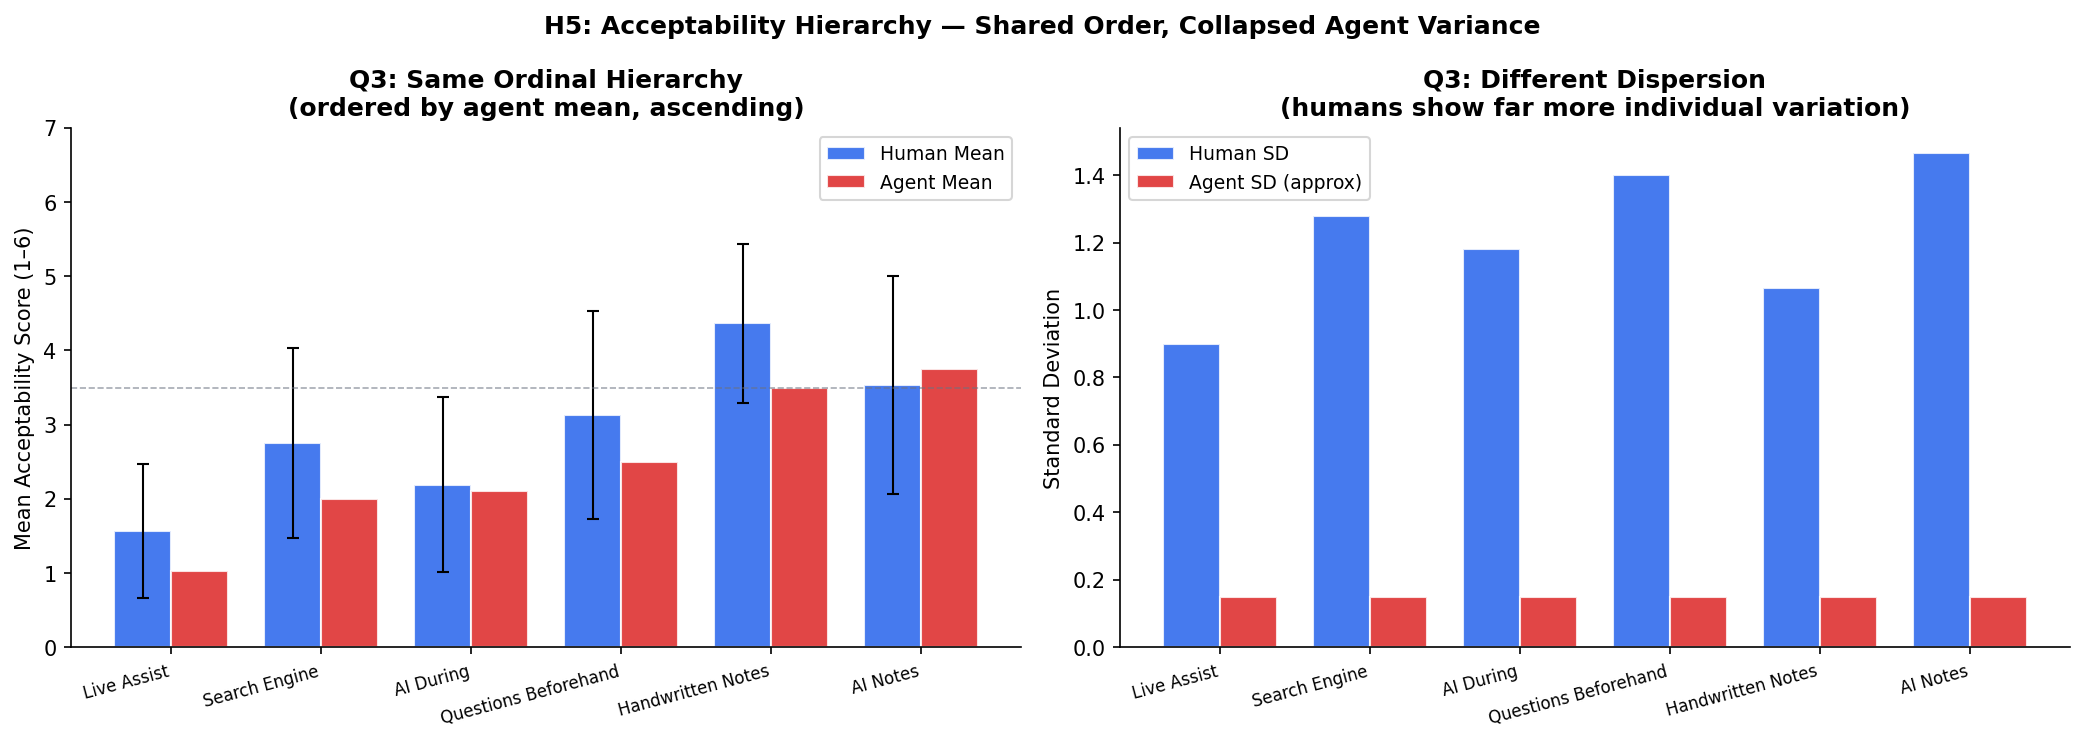

Saved: fig_h5_acceptability_hierarchy.png


In [57]:
# ── Figure 3: Acceptability — shared hierarchy, different dispersion ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by agent mean (to show hierarchy clearly)
agent_mean_vals = [agent_q3_means[c] for c in accept_n_cols]
sort_idx = np.argsort(agent_mean_vals)
sorted_labels  = [accept_short[i].replace('\n',' ') for i in sort_idx]
sorted_h_means = [human_accept_means[accept_n_cols[i]] for i in sort_idx]
sorted_h_sds   = [human_accept_sds[accept_n_cols[i]]   for i in sort_idx]
sorted_a_means = [agent_mean_vals[i] for i in sort_idx]

x = np.arange(len(accept_n_cols))
width = 0.38

# Left: mean comparison
ax = axes[0]
ax.bar(x - width/2, sorted_h_means, width, label='Human Mean',
       color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
ax.bar(x + width/2, sorted_a_means, width, label='Agent Mean',
       color=AGENT_COLOR, alpha=0.85, edgecolor='white')
ax.errorbar(x - width/2, sorted_h_means, yerr=sorted_h_sds,
            fmt='none', color='black', capsize=3, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Mean Acceptability Score (1–6)')
ax.set_ylim(0, 7)
ax.axhline(3.5, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
ax.legend(fontsize=9)
ax.set_title('Q3: Same Ordinal Hierarchy\n(ordered by agent mean, ascending)',
             fontweight='bold')

# Right: SD comparison (the dispersion gap)
ax2 = axes[1]
sorted_h_sds_arr = np.array(sorted_h_sds)
sorted_a_sds_arr = np.full(len(sorted_labels), agent_q3_std)
ax2.bar(x - width/2, sorted_h_sds_arr, width, label='Human SD',
        color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
ax2.bar(x + width/2, sorted_a_sds_arr, width, label='Agent SD (approx)',
        color=AGENT_COLOR, alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(sorted_labels, fontsize=8, rotation=15, ha='right')
ax2.set_ylabel('Standard Deviation')
ax2.set_title('Q3: Different Dispersion\n(humans show far more individual variation)',
              fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('H5: Acceptability Hierarchy — Shared Order, Collapsed Agent Variance',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h5_acceptability_hierarchy.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h5_acceptability_hierarchy.png')

---
## 7. Figure 4 — Convergence Items: Q21 Fairness and Q22 Reporting

> *"Q22 produced the most striking convergence... [X]% of humans and 98% of agents selecting 'Extremely Unlikely' or 'Somewhat Unlikely.'"*

> *"Q21 represents one of the closer alignments between the two samples."*

In [58]:
# ── Fill-in computations ───────────────────────────────────────────────────────
# Q22
q22_valid = df['q22_report_peer'].dropna()
q22_unlikely_human = (
    q22_valid.isin(['Extremely unlikely','Somewhat unlikely']).sum() /
    len(q22_valid) * 100 if len(q22_valid) > 0 else np.nan
)
print(f'── Q22 Peer Reporting ──')
print(f'  Human Ext/Smwt Unlikely : {q22_unlikely_human:.2f}%  (agent: 98%)')
print(f'\n── [X] FILL-IN: Q22 human unlikely %: {q22_unlikely_human:.2f}%')

# Q21
q21_valid = df['q21_fairness'].dropna()
print(f'\n── Q21 Fairness ──')
print(f'  Human mean : {q21_valid.map(fairness_map).mean():.3f}  SD: {q21_valid.map(fairness_map).std():.3f}')
print(f'  Agent mean : {agent_q21_mean:.3f}  SD: {agent_q21_std:.3f}')
if len(q21_valid) >= 2:
    t21, p21 = stats.ttest_ind(q21_valid.map(fairness_map).dropna(),
                                [2]*59 + [4]*91)
    print(f'  t-test (H vs A): t={t21:.3f}, p={p21:.3f}')

── Q22 Peer Reporting ──
  Human Ext/Smwt Unlikely : 82.48%  (agent: 98%)

── [X] FILL-IN: Q22 human unlikely %: 82.48%

── Q21 Fairness ──
  Human mean : 2.496  SD: 1.072
  Agent mean : 3.213  SD: 0.977
  t-test (H vs A): t=-5.919, p=0.000


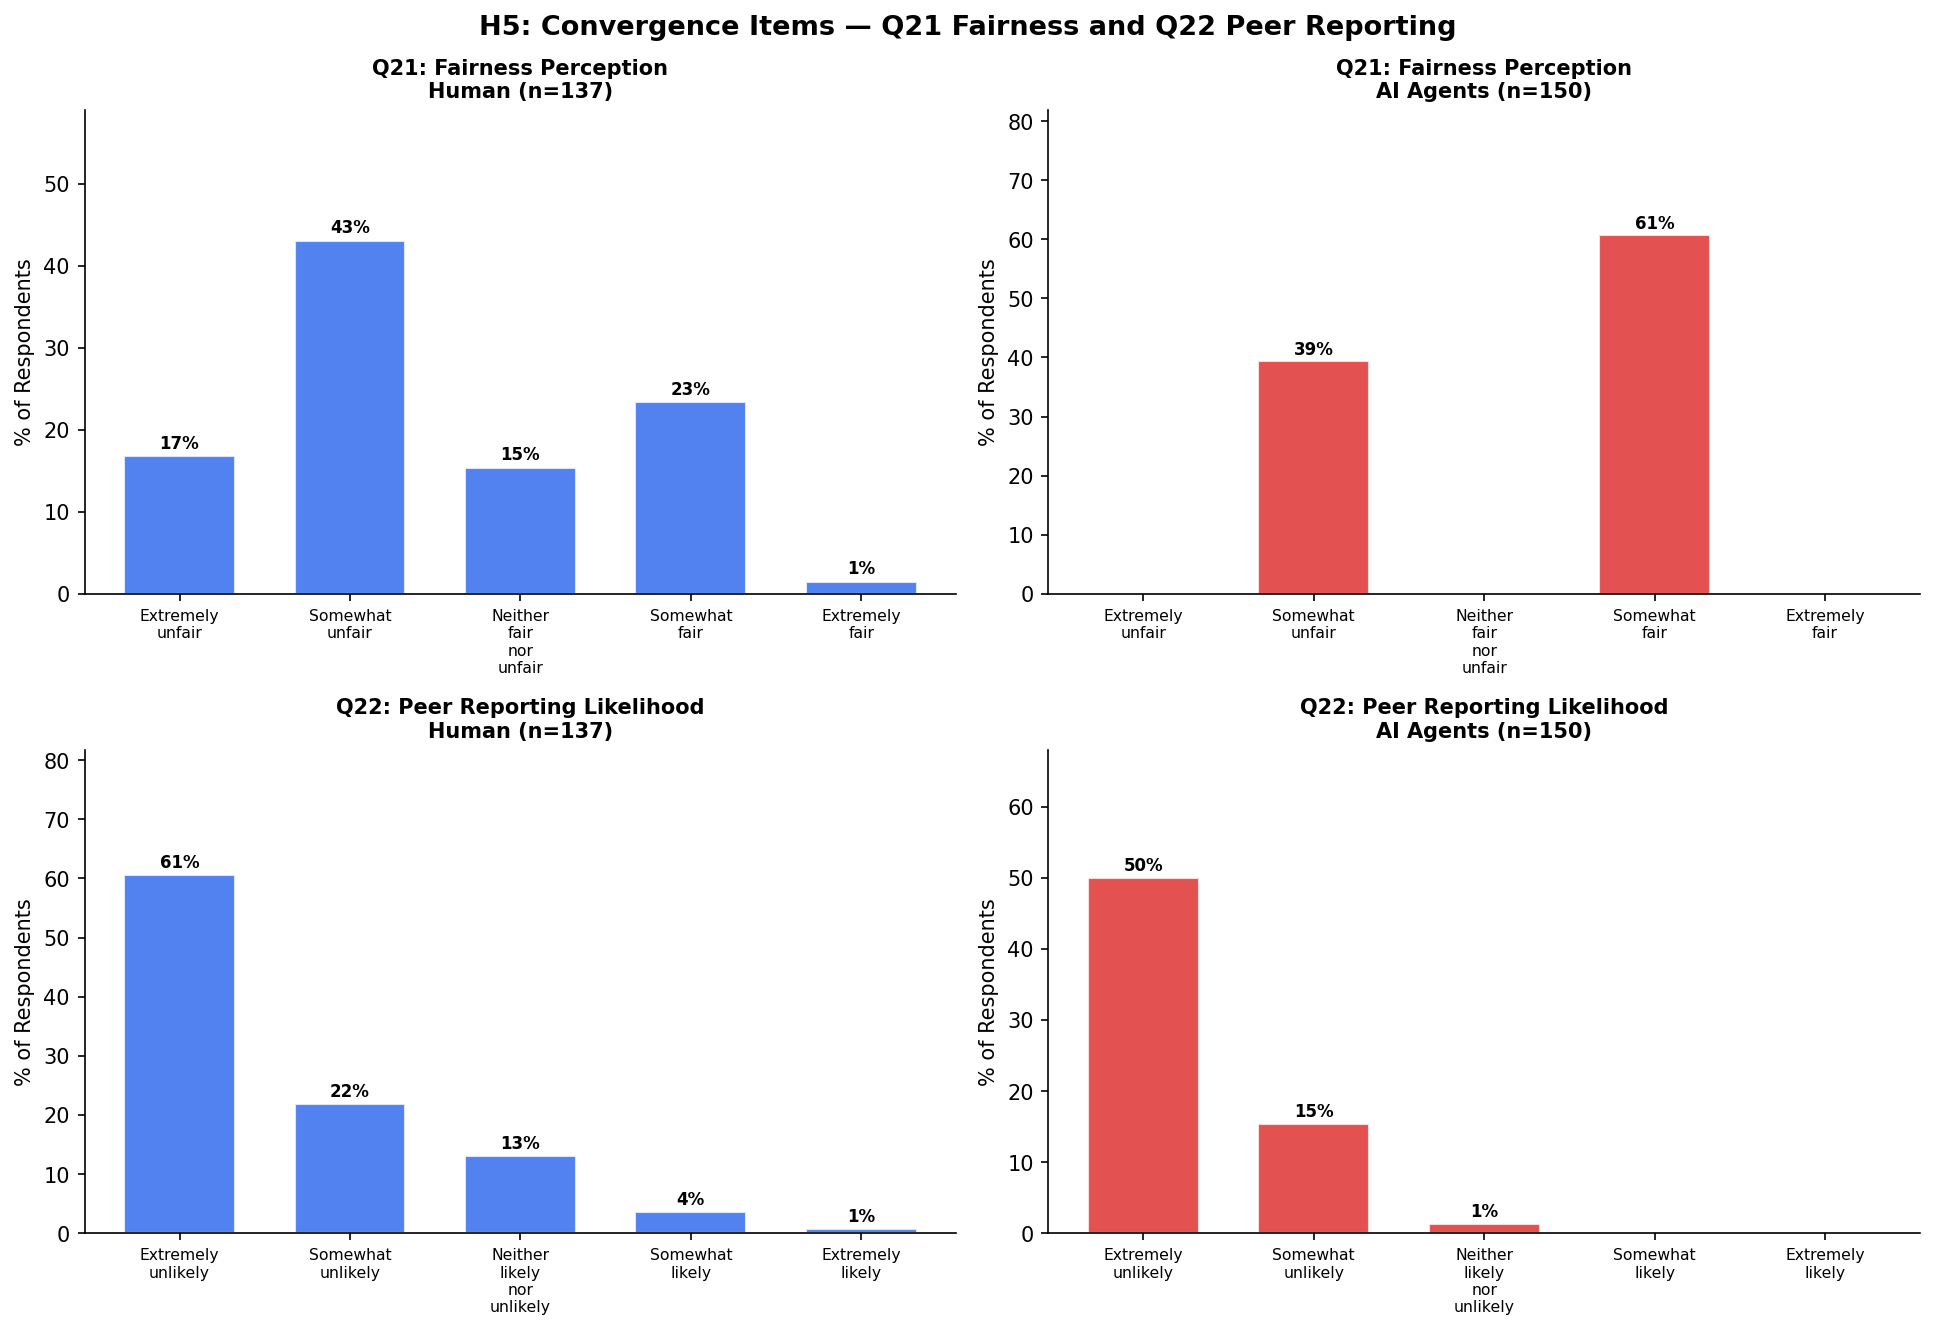

Saved: fig_h5_convergence_items.png


In [59]:
# ── Figure 4: Convergence items side-by-side ──────────────────────────────────
fairness_order = ['Extremely unfair','Somewhat unfair',
                  'Neither fair nor unfair','Somewhat fair','Extremely fair']
report_order   = ['Extremely unlikely','Somewhat unlikely',
                  'Neither likely nor unlikely','Somewhat likely','Extremely likely']

# Agent distributions
agent_q21_dist = pd.Series({'Extremely unfair':0,'Somewhat unfair':59,
                             'Neither Fair nor unfair':0,'Somewhat fair':91,'Extremely fair':0})
agent_q21_pct  = (agent_q21_dist / N_AGENTS * 100)

agent_q22_dist = pd.Series({'Extremely unlikely':75,'Somewhat unlikely':23,
                             'Neither likely nor unlikely':2,'Somewhat likely':0,'Extremely likely':0})
agent_q22_pct  = (agent_q22_dist / N_AGENTS * 100)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row_i, (q_col, labels, agent_pct, title_stem, n_valid) in enumerate([
    ('q21_fairness',  fairness_order, agent_q21_pct, 'Q21: Fairness Perception', df['q21_fairness'].notna().sum()),
    ('q22_report_peer', report_order, agent_q22_pct, 'Q22: Peer Reporting Likelihood', df['q22_report_peer'].notna().sum()),
]):
    q_valid = df[q_col].dropna()
    q_counts = q_valid.value_counts().reindex(labels, fill_value=0)
    q_pct    = (q_counts / len(q_valid) * 100) if len(q_valid) > 0 else q_counts * 0

    colors_dist = [CONVERGE_COLOR if c in ['Somewhat fair','Somewhat unfair',
                                            'Extremely unlikely','Somewhat unlikely'] else '#9CA3AF'
                   for c in labels]

    for col_i, (data, who, n_tot) in enumerate([
        (q_pct,      f'Human (n={n_valid})', n_valid),
        (agent_pct,  'AI Agents (n=150)',   N_AGENTS),
    ]):
        ax = axes[row_i][col_i]
        color = HUMAN_COLOR if col_i == 0 else AGENT_COLOR
        bars = ax.bar(range(len(labels)),
                      data.reindex(labels, fill_value=0).values,
                      color=color, alpha=0.8, edgecolor='white', width=0.65)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels([l.replace(' ','\n') for l in labels], fontsize=7.5)
        ax.set_ylabel('% of Respondents')
        max_v = max(data.reindex(labels, fill_value=0).values)
        ax.set_ylim(0, max(max_v * 1.3, 10) + 3)
        ax.set_title(f'{title_stem}\n{who}', fontweight='bold', fontsize=10)
        for bar, val in zip(bars, data.reindex(labels, fill_value=0).values):
            if val > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('H5: Convergence Items — Q21 Fairness and Q22 Peer Reporting',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h5_convergence_items.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h5_convergence_items.png')

---
## 8. Figure 5 — Divergence Items: Q23/Q24 Confidence and Q25 Consequence

> *"[X]% of human respondents selected 'Not Confident at All,' a response that no agent chose."*

> *"Agents converged uniformly on automatic disqualification while human respondents distributed across a range."*

In [60]:
# ── Fill-in computations ───────────────────────────────────────────────────────
confidence_order = ['Not confident at all','Slightly confident',
                    'Moderately confident','Very confident','Extremely confident']

q23_valid = df['q23_detect_confidence'].dropna()
q24_valid = df['q24_enforce_confidence'].dropna()

q23_not_conf = (q23_valid == 'Not confident at all').sum() / len(q23_valid) * 100 if len(q23_valid) > 0 else np.nan
q24_not_conf = (q24_valid == 'Not confident at all').sum() / len(q24_valid) * 100 if len(q24_valid) > 0 else np.nan

print('── Q23/Q24 Not Confident at All ──')
print(f'  Q23: {q23_not_conf:.2f}%  (agent: 0%)')
print(f'  Q24: {q24_not_conf:.2f}%  (agent: 0%)')
print(f'\n── [X] FILL-IN: % human "Not Confident at All" on Q23: {q23_not_conf:.2f}%')

# Q25
q25_valid = df['q25_consequence'].dropna()
q25_counts = q25_valid.value_counts()
print(f'\n── Q25 Consequence ──')
print(q25_counts.to_string())
print(f'  Agent: 100% automatic disqualification')

── Q23/Q24 Not Confident at All ──
  Q23: 44.53%  (agent: 0%)
  Q24: 30.66%  (agent: 0%)

── [X] FILL-IN: % human "Not Confident at All" on Q23: 44.53%

── Q25 Consequence ──
q25_consequence
Automatic disqualification from the current application.    101
Permanent ban from applying to the company.                  16
Warning, no penalty.                                          9
No consequence, as it's part of modern technology use.        6
Industry-wide ban                                             5
  Agent: 100% automatic disqualification


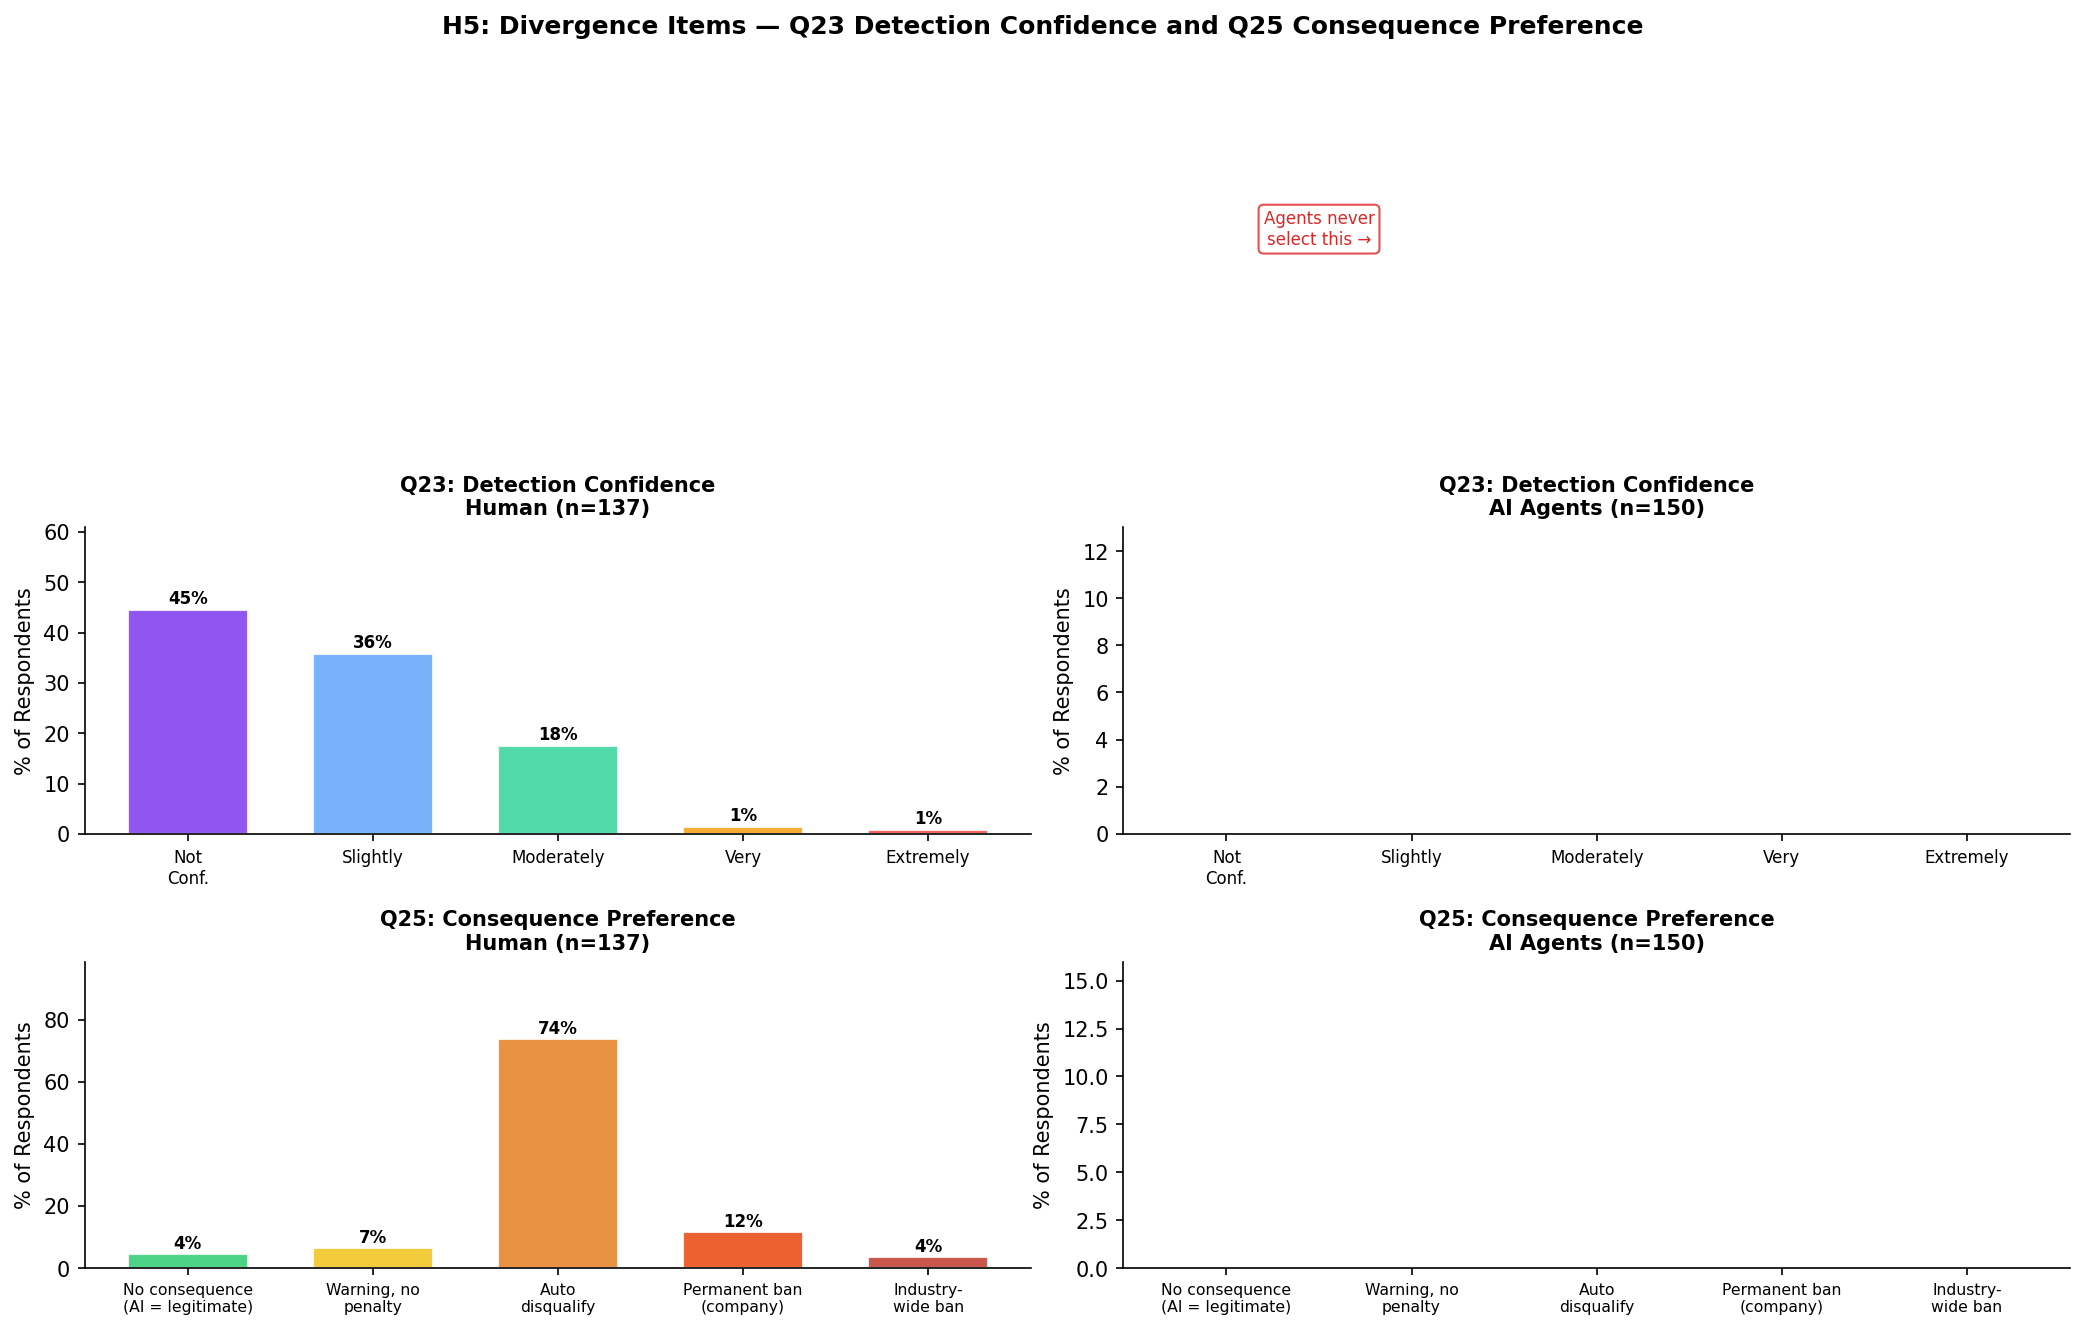

Saved: fig_h5_divergence_items.png


In [61]:
# ── Figure 5: Divergence items ─────────────────────────────────────────────────
# Agent Q23/Q24 distributions
agent_q23_dist = pd.Series({'Not Confident at All':0,'Slightly Confident':58,
                             'Moderately Confident':92,'Very Confident':0,'Extremely Confident':0})
agent_q24_dist = pd.Series({'Not Confident at All':0,'Slightly Confident':77,
                             'Moderately Confident':73,'Very Confident':0,'Extremely Confident':0})

consequence_labels = [
    'No consequence\n(AI = legitimate)',
    'Warning, no\npenalty',
    'Auto\ndisqualify',
    'Permanent ban\n(company)',
    'Industry-\nwide ban',
]
consequence_keys = [
    'No consequence, as it\'s part of modern technology use.',
    "Warning, no penalty.",
    'Automatic disqualification from the current application.',
    'Permanent ban from applying to the company.',
    'Industry-wide ban',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
conf_colors_bars = ['#7C3AED','#60A5FA','#34D399','#F59E0B','#EF4444']

# Q23 Human / Agent
for col_i, (data_raw, who, col_q) in enumerate([
    (df['q23_detect_confidence'], f'Human (n={df["q23_detect_confidence"].notna().sum()})', 'q23'),
    (pd.Series(['Slightly Confident']*58 + ['Moderately Confident']*92), 'AI Agents (n=150)', 'q23_a'),
]):
    ax = axes[0][col_i]
    counts = data_raw.value_counts().reindex(confidence_order, fill_value=0)
    n_tot  = len(data_raw.dropna())
    pcts   = (counts / n_tot * 100) if n_tot > 0 else counts * 0
    color  = HUMAN_COLOR if col_i == 0 else AGENT_COLOR
    bars   = ax.bar(range(len(confidence_order)), pcts.values,
                    color=conf_colors_bars, alpha=0.85, edgecolor='white', width=0.65)
    ax.set_xticks(range(len(confidence_order)))
    ax.set_xticklabels(['Not\nConf.','Slightly','Moderately','Very','Extremely'], fontsize=8)
    ax.set_ylabel('% of Respondents')
    max_v = max(pcts.values)
    ax.set_ylim(0, max(max_v * 1.3, 10) + 3)
    ax.set_title(f'Q23: Detection Confidence\n{who}', fontweight='bold', fontsize=10)
    for bar, val in zip(bars, pcts.values):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    if col_i == 1:  # annotate the absent category
        ax.annotate('Agents never\nselect this →',
                    xy=(0, 0), xytext=(0.5, 25),
                    fontsize=8, color=AGENT_COLOR, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=AGENT_COLOR, alpha=0.8))

# Q25 Human / Agent
n_q25 = len(q25_valid)
q25_human_pct = {k: q25_valid.value_counts().get(k, 0) / n_q25 * 100 if n_q25 > 0 else 0
                 for k in consequence_keys}
q25_agent_pct = {k: (100.0 if k == 'Automatic disqualification (current app).' else 0.0)
                 for k in consequence_keys}
conseq_colors_bars = ['#2ECC71','#F0C419','#E67E22','#E8450A','#C0392B']

for col_i, (data_pct, who) in enumerate([
    (q25_human_pct, f'Human (n={n_q25})'),
    (q25_agent_pct, 'AI Agents (n=150)'),
]):
    ax = axes[1][col_i]
    vals = [data_pct[k] for k in consequence_keys]
    bars = ax.bar(range(len(consequence_keys)), vals,
                  color=conseq_colors_bars, alpha=0.85, edgecolor='white', width=0.65)
    ax.set_xticks(range(len(consequence_keys)))
    ax.set_xticklabels(consequence_labels, fontsize=7.5)
    ax.set_ylabel('% of Respondents')
    max_v = max(vals) if max(vals) > 0 else 10
    ax.set_ylim(0, max_v * 1.3 + 3)
    ax.set_title(f'Q25: Consequence Preference\n{who}', fontweight='bold', fontsize=10)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('H5: Divergence Items — Q23 Detection Confidence and Q25 Consequence Preference',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h5_divergence_items.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h5_divergence_items.png')

---
## 9. Figure 6 — Typology: What Agents Can and Cannot Replicate

A summary visualization classifying every item by its divergence pattern, creating the typology the paper describes: *stable consensual norms* (agents do well) vs. *context-sensitive, pressure-driven variation* (agents fail).

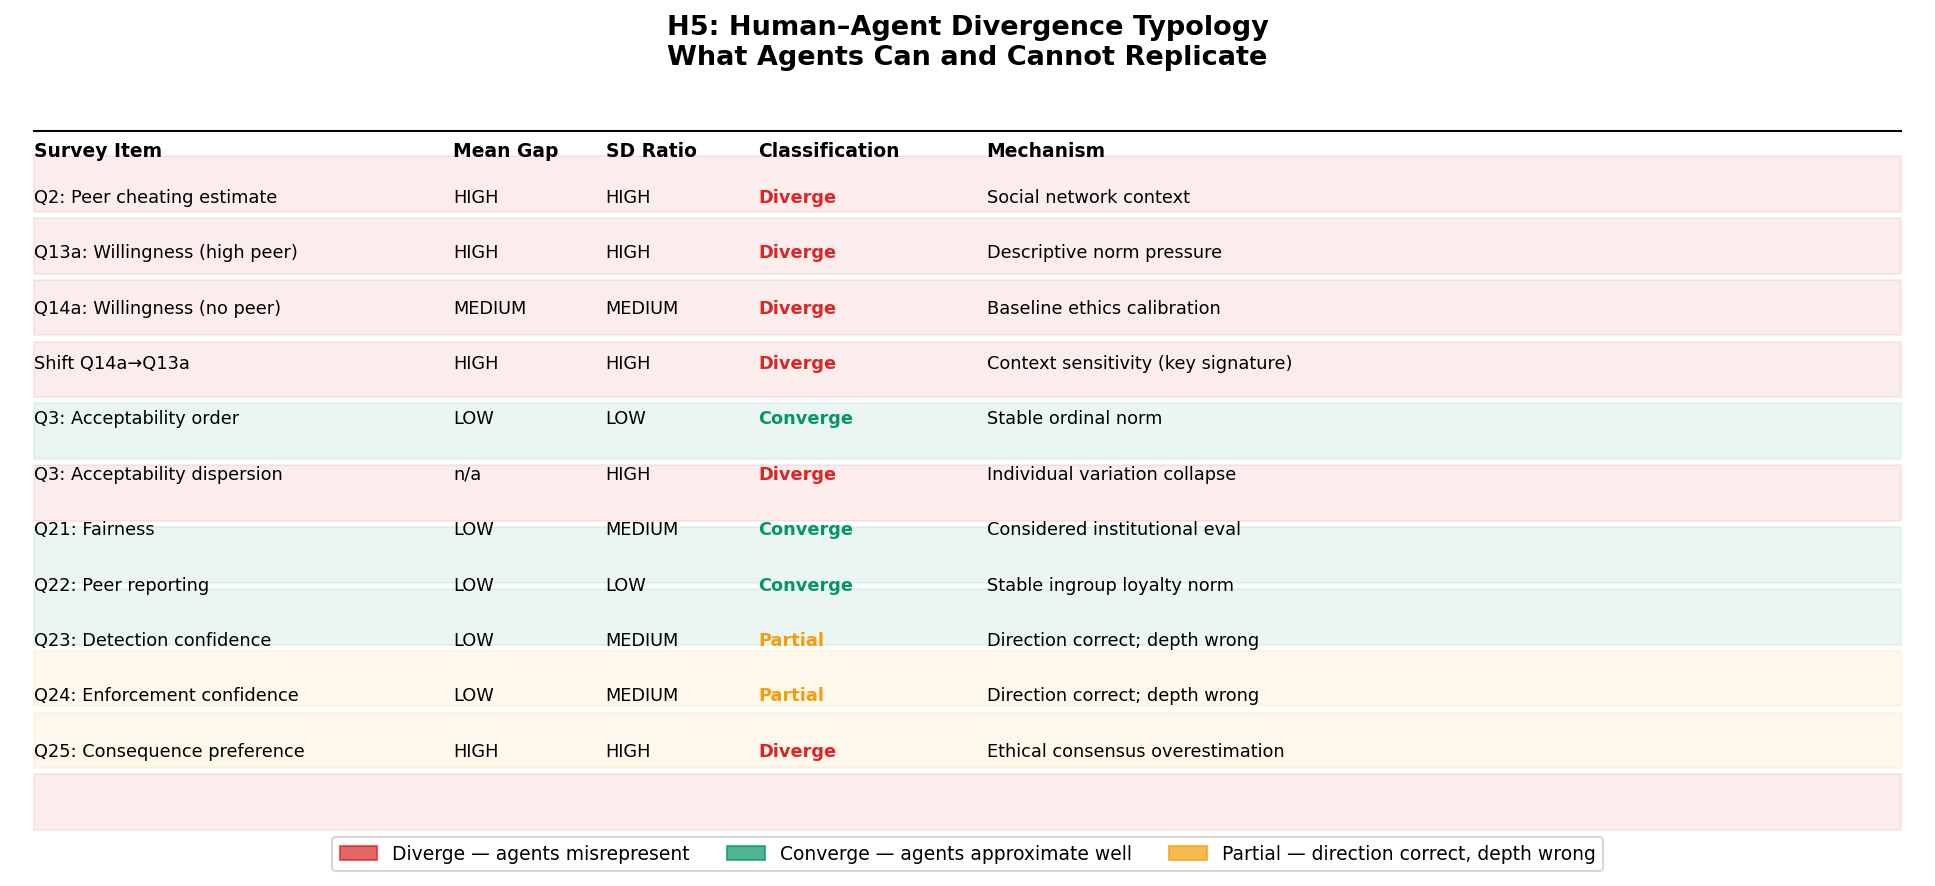

Saved: fig_h5_typology_table.png


In [62]:
# ── Build typology classification ─────────────────────────────────────────────
typology = [
    # (Item label, Gap magnitude, SD Ratio, Type, Mechanism)
    ('Q2: Peer cheating estimate',    'HIGH',   'HIGH',   'Diverge',  'Social network context'),
    ('Q13a: Willingness (high peer)', 'HIGH',   'HIGH',   'Diverge',  'Descriptive norm pressure'),
    ('Q14a: Willingness (no peer)',   'MEDIUM', 'MEDIUM', 'Diverge',  'Baseline ethics calibration'),
    ('Shift Q14a→Q13a',               'HIGH',   'HIGH',   'Diverge',  'Context sensitivity (key signature)'),
    ('Q3: Acceptability order',       'LOW',    'LOW',    'Converge', 'Stable ordinal norm'),
    ('Q3: Acceptability dispersion',  'n/a',    'HIGH',   'Diverge',  'Individual variation collapse'),
    ('Q21: Fairness',                 'LOW',    'MEDIUM', 'Converge', 'Considered institutional eval'),
    ('Q22: Peer reporting',           'LOW',    'LOW',    'Converge', 'Stable ingroup loyalty norm'),
    ('Q23: Detection confidence',     'LOW',    'MEDIUM', 'Partial',  'Direction correct; depth wrong'),
    ('Q24: Enforcement confidence',   'LOW',    'MEDIUM', 'Partial',  'Direction correct; depth wrong'),
    ('Q25: Consequence preference',   'HIGH',   'HIGH',   'Diverge',  'Ethical consensus overestimation'),
]

type_colors = {'Diverge': AGENT_COLOR, 'Converge': CONVERGE_COLOR, 'Partial': '#F59E0B'}
type_labels = {
    'Diverge' : 'Diverge — agents misrepresent',
    'Converge': 'Converge — agents approximate well',
    'Partial' : 'Partial — direction correct, depth wrong',
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.axis('off')

col_headers = ['Survey Item', 'Mean Gap', 'SD Ratio', 'Classification', 'Mechanism']
col_widths  = [0.22, 0.08, 0.08, 0.12, 0.35]
col_x = [0.01]
for w in col_widths[:-1]:
    col_x.append(col_x[-1] + w)

row_h = 0.072
y0 = 0.94

# Headers
for xi, hdr in zip(col_x, col_headers):
    ax.text(xi, y0, hdr, fontsize=9, fontweight='bold', va='top', transform=ax.transAxes)
ax.axhline(y0 - 0.01, xmin=0.01, xmax=0.99, color='black', linewidth=1)

# Rows
for i, (item, gap, sdr, typ, mech) in enumerate(typology):
    y = y0 - (i+1) * row_h
    bg_color = type_colors[typ]
    ax.axhspan(y - row_h*0.45, y + row_h*0.45,
               xmin=0.01, xmax=0.99, alpha=0.08, color=bg_color,
               transform=ax.transAxes)
    for xi, txt in zip(col_x, [item, gap, sdr, typ, mech]):
        color = type_colors[typ] if xi == col_x[3] else 'black'
        weight = 'bold' if xi == col_x[3] else 'normal'
        ax.text(xi, y, txt, fontsize=8.5, va='center', color=color,
                fontweight=weight, transform=ax.transAxes)

# Legend
legend_patches = [mpatches.Patch(color=c, alpha=0.7, label=type_labels[t])
                  for t, c in type_colors.items()]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.02),
          fontsize=9, ncol=3)

ax.set_title('H5: Human–Agent Divergence Typology\nWhat Agents Can and Cannot Replicate',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('fig_h5_typology_table.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h5_typology_table.png')

---
## 10. Figure 7 — Radar / Spider Chart: Item-by-Item Divergence Profile

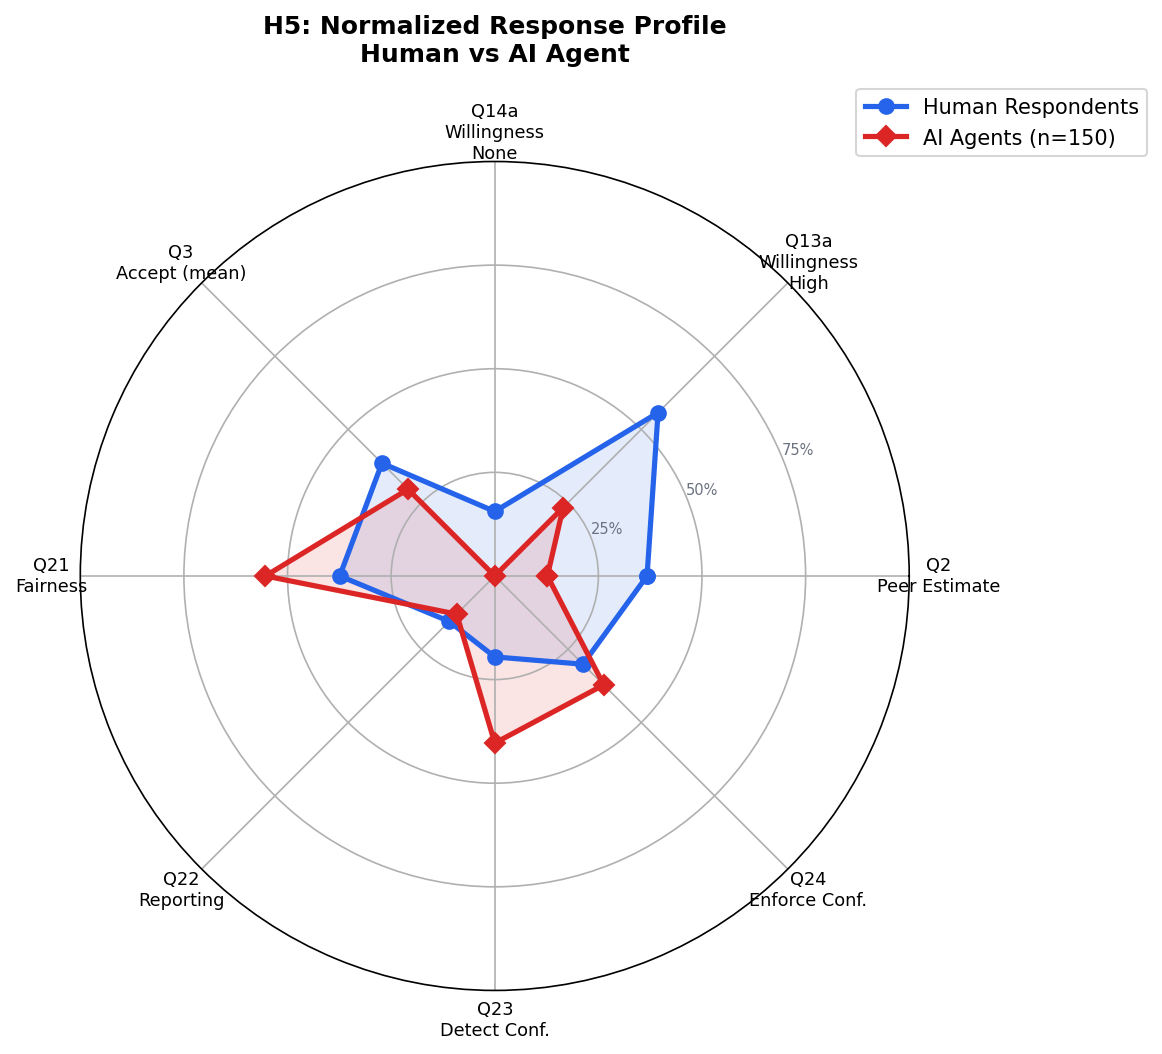

Saved: fig_h5_radar_profile.png


In [63]:
# ── Figure 7: Radar chart — human vs agent normalised means ───────────────────
# Normalise each item to 0–1 scale for comparability
radar_items = [
    ('Q2\nPeer Estimate',      df['q2_n'].mean(),   agent_q2_mean,     0, 100),
    ('Q13a\nWillingness\nHigh',df['q13a_n'].mean(), agent_q13a_mean,   1, 5),
    ('Q14a\nWillingness\nNone',df['q14a_n'].mean(), agent_q14a_mean,   1, 5),
    ('Q3\nAccept (mean)',       df[accept_n_cols].mean().mean(),
                                np.mean(list(agent_q3_means.values())), 1, 6),
    ('Q21\nFairness',          df['q21_n'].mean(),  agent_q21_mean,    1, 5),
    ('Q22\nReporting',         df['q22_n'].mean(),  agent_q22_mean,    1, 5),
    ('Q23\nDetect Conf.',      df['q23_n'].mean(),  agent_q23_mean,    1, 5),
    ('Q24\nEnforce Conf.',     df['q24_n'].mean(),  agent_q24_mean,    1, 5),
]

labels_radar = [r[0] for r in radar_items]
human_norm   = [(r[1] - r[3]) / (r[4] - r[3]) if not np.isnan(r[1]) else 0.5 for r in radar_items]
agent_norm   = [(r[2] - r[3]) / (r[4] - r[3]) for r in radar_items]

# Negate scales so higher = more cheating-permissive
# (Q21 fairness / Q22 reporting / Q23 Q24 confidence are not cheating-permissive — leave as is)

N_items = len(labels_radar)
angles  = [n / float(N_items) * 2 * np.pi for n in range(N_items)]
angles += angles[:1]  # close the loop
human_vals = human_norm + human_norm[:1]
agent_vals = agent_norm + agent_norm[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, human_vals, color=HUMAN_COLOR, linewidth=2.5, marker='o', markersize=7, label='Human Respondents')
ax.fill(angles, human_vals, color=HUMAN_COLOR, alpha=0.12)
ax.plot(angles, agent_vals, color=AGENT_COLOR, linewidth=2.5, marker='D', markersize=7, label='AI Agents (n=150)')
ax.fill(angles, agent_vals, color=AGENT_COLOR, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=8.5)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%', '50%', '75%'], fontsize=7, color=NEUTRAL_COLOR)
ax.set_title('H5: Normalized Response Profile\nHuman vs AI Agent',
             fontweight='bold', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('fig_h5_radar_profile.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h5_radar_profile.png')

---
## 11. Summary: All [X] Fill-In Values for LaTeX

In [64]:
print('=' * 68)
print('H5 FILL-IN REFERENCE SHEET')
print('=' * 68)

def fmt(v, suffix='', dec=1):
    return f'{v:.{dec}f}{suffix}' if not (isinstance(v, float) and np.isnan(v)) else '[no data]'

# ── Q22 reporting ─────────────────────────────────────────────────────────────
print('\n── Q22: Peer Reporting Convergence ──')
print(f'  [X]% of humans Ext/Smwt Unlikely : {fmt(q22_unlikely_human, "%")}')
print(f'  Agent: 98%')

# ── Q23/Q24 Not Confident at All ──────────────────────────────────────────────
print('\n── Q23/Q24: Not Confident at All ──')
print(f'  [X]% humans Not Conf. Q23 : {fmt(q23_not_conf, "%")}')
print(f'  [X]% humans Not Conf. Q24 : {fmt(q24_not_conf, "%")}')
print(f'  Agent: 0% on both')

# ── Context sensitivity ───────────────────────────────────────────────────────
print('\n── Context Sensitivity (Q14a → Q13a Shift) ──')
print(f'  Human mean shift  : {fmt(human_shift_mean, "", dec=3)}')
print(f'  Agent mean shift  : {fmt(agent_shift_mean, "", dec=3)}')
print(f'  Human Q14a mean   : {fmt(human_q14a_mean, "", dec=3)}')
print(f'  Human Q13a mean   : {fmt(human_q13a_mean, "", dec=3)}')

# ── Acceptability rank correlation ────────────────────────────────────────────
print('\n── Q3 Acceptability Hierarchy ──')
print(f'  Human/Agent rank correlation : r={rho_rank:.3f}, p={p_rank:.3f}')
print(f'  Mean human SD : {human_accept_sds.mean():.3f}')
print(f'  Agent SD (approx) : {agent_q3_std:.3f}')
print(f'  SD ratio (H/A) : {human_accept_sds.mean()/agent_q3_std:.1f}x')

# ── Q21 fairness ──────────────────────────────────────────────────────────────
print('\n── Q21 Fairness ──')
q21_n = df['q21_n'].dropna()
print(f'  Human mean : {fmt(q21_n.mean(), "", dec=3)}')
print(f'  Agent mean : {fmt(agent_q21_mean, "", dec=3)}')
print(f'  Gap        : {fmt(q21_n.mean() - agent_q21_mean, "", dec=3)}')

# ── Master divergence table summary ──────────────────────────────────────────
print('\n── Master Divergence Table (sorted by gap) ──')
for _, row in summary_df.sort_values('Gap (H-A)', ascending=False, key=abs).iterrows():
    print(f'  {row["Item"]:<45} gap={fmt(row["Gap (H-A)"], "", dec=3):>10}  [{row["Category"]}]')

print('\n' + '=' * 68)
print('NOTE: [no data] values will populate once the full sample is collected.')
print('      Re-run all cells top-to-bottom after each data update.')

H5 FILL-IN REFERENCE SHEET

── Q22: Peer Reporting Convergence ──
  [X]% of humans Ext/Smwt Unlikely : 82.5%
  Agent: 98%

── Q23/Q24: Not Confident at All ──
  [X]% humans Not Conf. Q23 : 44.5%
  [X]% humans Not Conf. Q24 : 30.7%
  Agent: 0% on both

── Context Sensitivity (Q14a → Q13a Shift) ──
  Human mean shift  : 1.606
  Agent mean shift  : 0.933
  Human Q14a mean   : 1.622
  Human Q13a mean   : 3.229

── Q3 Acceptability Hierarchy ──
  Human/Agent rank correlation : r=0.886, p=0.019
  Mean human SD : 1.216
  Agent SD (approx) : 0.150
  SD ratio (H/A) : 8.1x

── Q21 Fairness ──
  Human mean : 2.496
  Agent mean : 3.213
  Gap        : -0.717

── Master Divergence Table (sorted by gap) ──
  Q2: Peer cheat estimate (%)                   gap=    24.043  [Social Context]
  Q13a: Willingness (high peer)                 gap=     1.296  [Social Context]
  Q3: Acceptability — Handwritten Notes         gap=     0.864  [Acceptability Hierarchy]
  Q23: Detection confidence                    